In [3]:
from math import prod

classes = ["Spam", "Ham"]
prior = {"Spam": 0.4, "Ham": 0.6}
likelihood = {
    "Spam": {"free": 0.7, "urgent": 0.6},
    "Ham": {"free": 0.2, "urgent": 0.1},
}
X = ["free", "urgent"]

scores = {}
for c in classes:
    #### [ 빈칸: 이 부분을 직접 코딩하세요 ]
    # 목표: 텍스트 풀이에서 계산한 P(X|C)*P(C)를 코드로 재현
    px_given_c = prod([likelihood[c][token] for token in X])
    scores[c] = px_given_c * prior[c]

pred = max(scores, key=scores.get)
print("NB scores:", scores)
print("NB prediction:", pred)

NB scores: {'Spam': 0.168, 'Ham': 0.012000000000000002}
NB prediction: Spam


In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

#훈련 데이터
train_texts = ["free urgent offer", "free free urgent", "meeting schedule", "project discussion"]
labels = ['Spam', 'Spam', 'Ham', 'Ham']
# 테스트 => 숫자
vectorizer = CountVectorizer()
x_train = vectorizer.fit_transform(train_texts)
model=MultinomialNB()
model.fit(x_train,labels)
# 예측할 문장
test_text = ['free urgent']
x_test = vectorizer.transform(test_text)
pred = model.predict(x_test)
proba = model.predict_proba(x_test)
pred , proba, 

(array(['Spam'], dtype='<U4'), array([[0.10425663, 0.89574337]]))

In [15]:
print('class prior p(C)')
print(model.class_log_prior_)

print("feature log probabilty p(word|C)")
print(model.feature_log_prob_)

print('vocabulary')
print(vectorizer.get_feature_names_out())

class prior p(C)
[-0.69314718 -0.69314718]
feature log probabilty p(word|C)
[[-1.70474809 -2.39789527 -1.70474809 -2.39789527 -1.70474809 -1.70474809
  -2.39789527]
 [-2.56494936 -1.178655   -2.56494936 -1.87180218 -2.56494936 -2.56494936
  -1.46633707]]
vocabulary
['discussion' 'free' 'meeting' 'offer' 'project' 'schedule' 'urgent']


In [ ]:
# iris data를 가지고 품종 분류
from sklearn.naive_bayes import MultinomialNB
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

data = load_iris()
X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)


model=MultinomialNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_proba = model.predict_proba(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# k-NN
from math import sqrt
from collections import Counter

train_X = [[1, 1], [2, 1], [4, 4], [5, 4]]
train_y = [0, 0, 1, 1]
query = [3, 2]
k = 3

def euclidean(p, q):
    #### [ 빈칸: 이 부분을 직접 코딩하세요 ]
    # 목표: 텍스트 풀이에서 계산한 sqrt(Σ(p_i - q_i)^2)를 코드로 재현
    return sqrt(sum((pi - qi) ** 2 for pi, qi in zip(p, q)))

dists = [(euclidean(x, query), y) for x, y in zip(train_X, train_y)]
dists.sort(key=lambda t: t[0])
knn = [label for _, label in dists[:k]]
pred = Counter(knn).most_common(1)[0][0] # Counter : 개수를 세줌 .most_common: 가장 많이 나온

print("k-NN sorted distances:", dists)
print("k-NN neighbors:", knn)
print("k-NN prediction:", pred)

k-NN sorted distances: [(1.4142135623730951, 0), (2.23606797749979, 0), (2.23606797749979, 1), (2.8284271247461903, 1)]
k-NN neighbors: [0, 0, 1]
k-NN prediction: 0


In [90]:
from math import sqrt
import numpy as np
from collections import Counter

train_X = np.array([[1, 1], [2, 1], [4, 4], [5, 4]])
train_y = np.array([0, 0, 1, 1])
query = np.array([3, 2])
k = 3

def euclidean(p, q):
    return sqrt(sum((p-q)**2))

dists = [(euclidean(query,x), int(y)) for x,y in zip(train_X, train_y)]
dists

[(2.23606797749979, 0),
 (1.4142135623730951, 0),
 (2.23606797749979, 1),
 (2.8284271247461903, 1)]

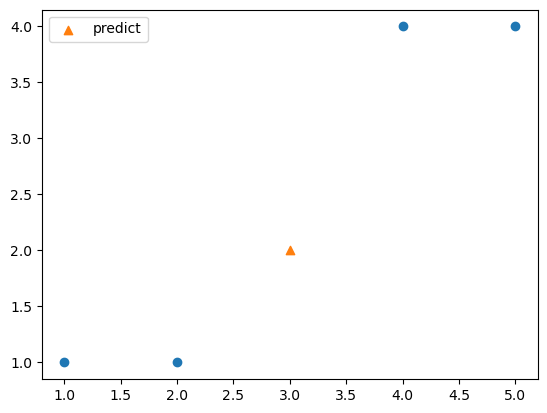

In [84]:
import matplotlib.pyplot as plt
import numpy as np

train_X = np.array([[1, 1], [2, 1], [4, 4], [5, 4]])
train_y = np.array([0, 0, 1, 1])
query = np.array([3, 2])
plt.scatter(train_X[:,0], train_X[:,1])
plt.scatter(query[0],query[1], label= 'predict', marker='^')
plt.legend()
plt.show()

In [137]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

data = load_iris()
X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('k_NN', KNeighborsClassifier(n_neighbors=5))
])
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [134]:
# 최적의 k 찾기
# k = 1, 2, 3, ... N
# 각 k의 값에 따른 교차검증 (cv=5)을 해서 (score, k) 리스트로 저장
# score가 가장 높을 때의 k의 값을 출력
from sklearn.model_selection import cross_val_score

ks = [1, 3, 5, 7, 10, 15]
score_list = []

for k in ks:
    pipeline = Pipeline([
    # ('scaler', StandardScaler()),
    ('k_NN', KNeighborsClassifier(n_neighbors=k))
    ])
    score = cross_val_score(pipeline, x_train, y_train, cv=5)
    mean_score = score.mean()
    score_list.append((mean_score, k))

score_list.sort(key=lambda x : x[0], reverse=True)
print(score_list[0])
best_k = score_list[0][1]
best_k

(np.float64(0.975), 5)


5

In [135]:
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(x_train, y_train)
print(classification_report(y_test, best_model.predict(x_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

